 # Описание набора данных
В этом соревновании задача - предсказать, был ли пассажир перенесен в альтернативное измерение во время столкновения космического корабля "Титаник" с пространственно-временной аномалией. Чтобы помочь вам сделать эти прогнозы, вам предоставляется набор личных записей, извлеченных из поврежденной компьютерной системы корабля.

- Описания файлов и полей данных
    - 1.train.csv - Личные записи примерно двух третей (~ 8700) пассажиров, которые будут использоваться в качестве обучающих данных.
    - 2.PassengerId - Уникальный идентификатор для каждого пассажира. Каждый идентификатор принимает форму, gggg_pp где gggg указывается группа, с которой путешествует пассажир, и pp его номер в группе. Люди в группе часто являются членами семьи, но не всегда.
    - 3. HomePlanet - Планета, с которой вылетел пассажир, обычно планета его постоянного проживания.
    - 4. CryoSleep - Указывает, решил ли пассажир погрузиться в анабиоз на время полета. Пассажиры в криосне прикованы к своим каютам.
    - 5. Cabin - Номер каюты, в которой находится пассажир. Принимает форму, deck/num/sideгде side может быть либо P для левого, либо S для правого борта.
    - 6. Destination - Планета, на которой высадится пассажир.
    - 7. Age - Возраст пассажира.
    - 8. VIP - Оплатил ли пассажир специальное VIP-обслуживание во время путешествия.
    - 9. RoomServiceFoodCourt, ShoppingMallSpa, VRDeck - Сумма, которую пассажир выставил за пользование всеми многочисленными удобствами класса люкс на "Космическом корабле "Титаник"".
    - 10. Name - Имя и фамилия пассажира.
    - 11. Transported - Был ли пассажир перенесен в другое измерение. Это цель, столбец, который вы пытаетесь предсказать.
    
- test.csv - Личные записи для оставшейся трети (~ 4300) пассажиров, которые будут использоваться в качестве тестовых данных. Ваша задача - предсказать стоимость Transported для пассажиров в этом наборе.
- <strong>sample_submission.csv</strong> - файл отправки в правильном формате.
    - PassengerId - Идентификатор для каждого пассажира в тестовом наборе.
    - Transported - Цель. Для каждого пассажира предскажите либо True, либо False.

##### данные взяты с https://www.kaggle.com/competitions/spaceship-titanic

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import random

from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder, scale


from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier

In [2]:
df_sample_submission = pd.read_csv('sample_submission.csv')
df = pd.read_csv('train.csv')
df_pred = pd.read_csv('test.csv')
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [3]:
print("\033[1m" + "\033[30m" + 'nan значения в основной таблице:' + "\033[0m")
print(df.isna().sum())
print('-------------------')
print("\033[1m" + "\033[30m" + 'nan значения в таблице для предсказания:' + "\033[0m")
print(df_pred.isna().sum())

nan значения в основной таблице:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64
-------------------
nan значения в таблице для предсказания:
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64


In [4]:
print("\033[1m" + "\033[30m" + 'Типы данных  в основной таблице:' + "\033[0m")
print(df.dtypes)
print('-----------------------')
print("\033[1m" + "\033[30m" + 'Типы данных в таблице для предсказания:' + "\033[0m")
print(df.dtypes)

Типы данных  в основной таблице:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object
-----------------------
Типы данных в таблице для предсказания:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


In [5]:
print("\033[1m" + "\033[30m" + 'Статистика для основных данных:' + "\033[0m")
print(df.describe())
print('-' * 74)
print("\033[1m" + "\033[30m" + 'Статистика для предсказательных данных:' + "\033[0m")
print(df_pred.describe())

Статистика для основных данных:
               Age   RoomService     FoodCourt  ShoppingMall           Spa   
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000  \
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  
-------------------------------------------------------------------

In [6]:
print('Количество пассажиров перенесенных в другое измерение:', len(df.loc[df['Transported'] == True]))
print('Количество пассажиров не перенесенных в другое измерение:', len(df.loc[df['Transported'] == False]))

Количество пассажиров перенесенных в другое измерение: 4378
Количество пассажиров не перенесенных в другое измерение: 4315


In [7]:
# повторов нет
print(df.duplicated().sum())
print(df_pred.duplicated().sum())

0
0


# Подготовка данных

## 'PassengerId'

In [8]:
# Основные данные

# Создание столбца Group
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0]).astype('int')

# Создание столбца Number
df['Number'] = (df['PassengerId'].apply(lambda x: x.split('_')[1])).astype('int')

# Удаление столбца PassengerId
df = df.drop('PassengerId', axis=1)

## 'Transported'

In [9]:
# Преобразование
df['Transported'] = df['Transported'].replace({False: 0, True: 1})

## 'CryoSleep', 'HomePlanet', 'VIP'

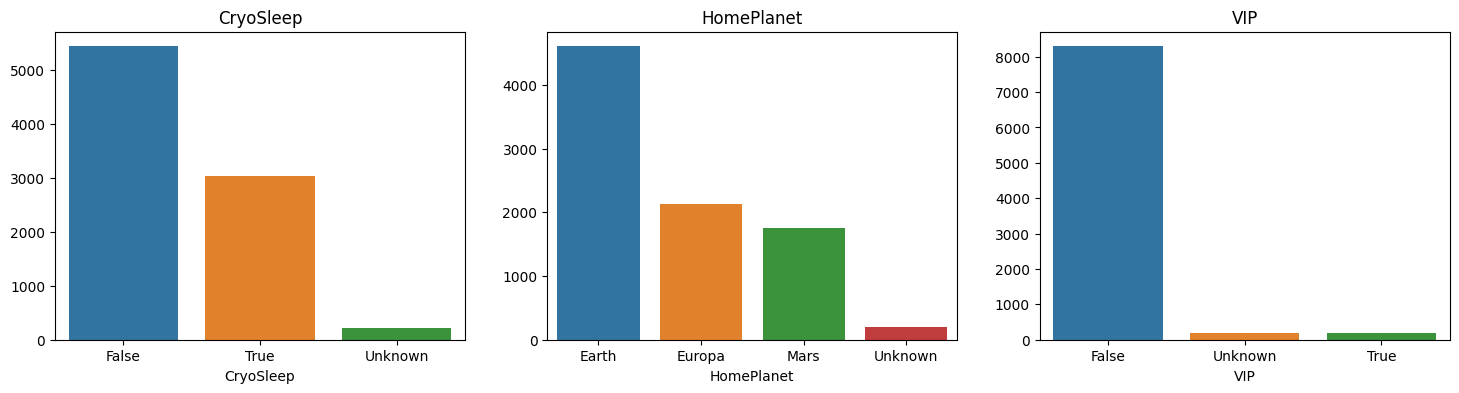

In [10]:
# Задаем размеры графиков
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 4))

# Строим первый график
CryoSleep_ = df['CryoSleep'].fillna('Unknown').value_counts()
sns.barplot(x=CryoSleep_.index, y=CryoSleep_.values, ax=ax1)
ax1.set_title('CryoSleep')

# Строим второй график
HomePlanet_ = df['HomePlanet'].fillna('Unknown').value_counts()
sns.barplot(x=HomePlanet_.index, y=HomePlanet_.values, ax=ax2)
ax2.set_title('HomePlanet')

# Строим третий график
VIP_ = df['VIP'].fillna('Unknown').value_counts()
sns.barplot(x=VIP_.index, y=VIP_.values, ax=ax3)
ax3.set_title('VIP')

# Отображаем графики
plt.show()

In [11]:
le = LabelEncoder()
# заменяем пропущенные значения на наиболее часто встречающееся значение в столбцах 'CryoSleep', 'HomePlanet' и 'VIP'
columns_to_ = ['CryoSleep', 'HomePlanet', 'VIP']
for column in columns_to_:
    df[column].fillna(df[column].mode()[0], inplace=True)
    
# преобразуем столбцы 'CryoSleep', 'HomePlanet' и 'VIP' в числовой формат
for column in columns_to_:
    df[column] = le.fit_transform(df[column])

## 'Cabin'

In [12]:
# Берем только последнию букву, оставляем nan значения без изменений
def process_cabin(cabin):
    if isinstance(cabin, str):
        return cabin[-1]
    else:
        return cabin

df['Cabin'] = df['Cabin'].apply(process_cabin)

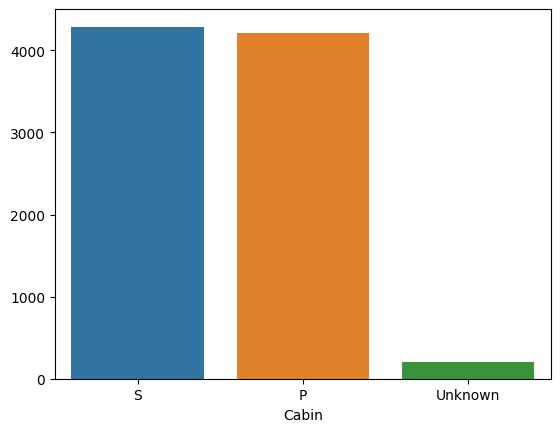

In [13]:
# Строим график
Cabin_ = df['Cabin'].fillna('Unknown').value_counts()
sns.barplot(x=Cabin_.index, y=Cabin_.values);

In [14]:
# замена "nan" на случайную категорию кабины
df['Cabin'] = df['Cabin'].apply(lambda x: random.choice(['P', 'S']) if pd.isnull(x) else x)

# преобразование в числовой формат
df['Cabin'] = le.fit_transform(df['Cabin'])

## 'Destination'

In [15]:
df.Destination.unique()

array(['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan], dtype=object)

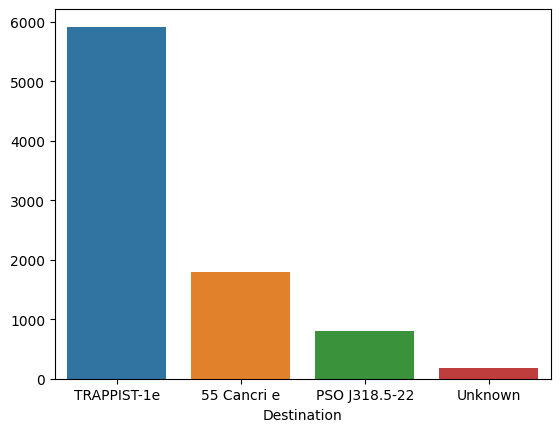

In [16]:
# Строим график
Destination_ = df['Destination'].fillna('Unknown').value_counts()
sns.barplot(x=Destination_.index, y=Destination_.values);

In [17]:
# заменяем пропущенные значения на наиболее часто встречающееся значение
df['Destination'].fillna(df['Destination'].mode()[0], inplace=True)

# преобразование в числовой формат
df['Destination'] = le.fit_transform(df['Destination'])

## 'Age'

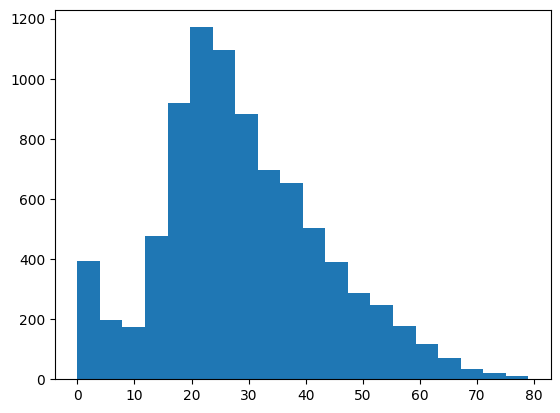

In [18]:
# создаем график
plt.hist(df['Age'], bins=20)

plt.show()

In [19]:
# создаем датафреймы с пропущенными и заполненными значениями
df_missing = df[df['Age'].isnull()]
df_not_missing = df[df['Age'].notnull()]

# выбираем признаки, которые будем использовать для обучения модели
X_train = df_not_missing[['HomePlanet', 'CryoSleep', 'Cabin', 'VIP', 'Group', 'Number']]
y_train = df_not_missing['Age']

# создаем модель
rf = RandomForestRegressor()

# обучаем модель на имеющихся данных
rf.fit(X_train, y_train)

# предсказываем значения для пропущенных значений
X_test = df_missing[['HomePlanet', 'CryoSleep', 'Cabin', 'VIP', 'Group', 'Number']]
predicted_age = rf.predict(X_test)

# заменяем пропущенные значения на предсказанные
df.loc[df['Age'].isnull(), 'Age'] = predicted_age

# Приводим значения к int
df['Age'] = df['Age'].astype(int)

## 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'

In [20]:
# Заменяем nan значения на 0.0
df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(0.0)

# удаляем Name
df = df.drop('Name', axis=1)

print(df.isna().sum())
print('-----')
print(df.dtypes)

HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Group           0
Number          0
dtype: int64
-----
HomePlanet        int32
CryoSleep         int64
Cabin             int32
Destination       int32
Age               int32
VIP               int64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported       int64
Group             int32
Number            int32
dtype: object


In [21]:
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,Number
0,1,0,0,2,39,0,0.0,0.0,0.0,0.0,0.0,0,1,1
1,0,0,1,2,24,0,109.0,9.0,25.0,549.0,44.0,1,2,1
2,1,0,1,2,58,1,43.0,3576.0,0.0,6715.0,49.0,0,3,1
3,1,0,1,2,33,0,0.0,1283.0,371.0,3329.0,193.0,0,3,2
4,0,0,1,2,16,0,303.0,70.0,151.0,565.0,2.0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,1,0,0,0,41,1,0.0,6819.0,0.0,1643.0,74.0,0,9276,1
8689,0,1,1,1,18,0,0.0,0.0,0.0,0.0,0.0,0,9278,1
8690,0,0,1,2,26,0,0.0,0.0,1872.0,1.0,0.0,1,9279,1
8691,1,0,1,0,32,0,0.0,1049.0,0.0,353.0,3235.0,0,9280,1


## Все тоже самое для df_pred

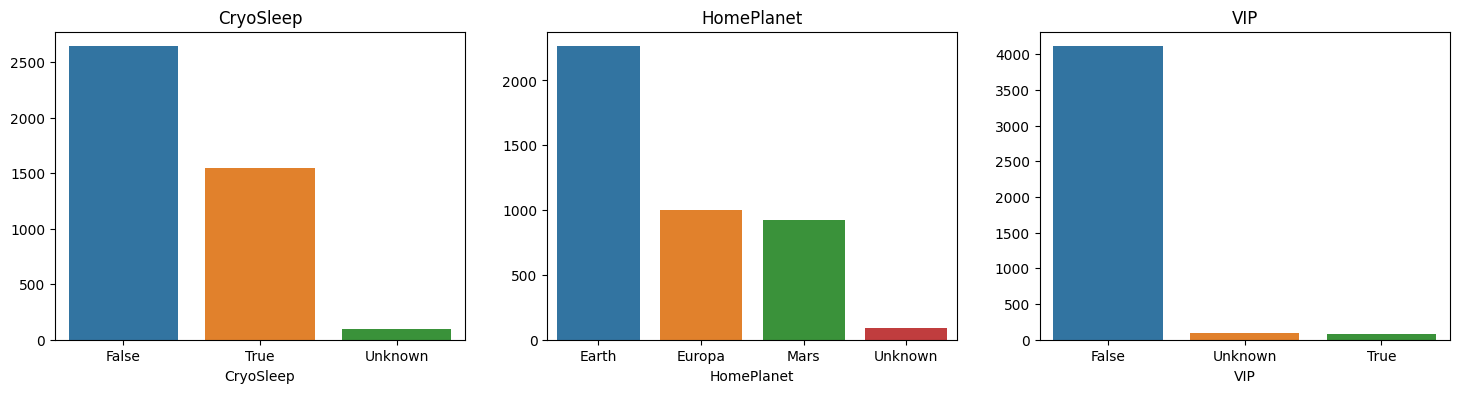

In [22]:
X_pred = df_pred

# Создание столбца Group
X_pred['Group'] = X_pred['PassengerId'].apply(lambda x: x.split('_')[0]).astype('int')

# Создание столбца Number
X_pred['Number'] = (X_pred['PassengerId'].apply(lambda x: x.split('_')[1])).astype('int')

# Удаление столбца PassengerId
X_pred = X_pred.drop('PassengerId', axis=1)

# Задаем размеры графиков
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 4))

# Строим первый график
CryoSleep_pred = X_pred['CryoSleep'].fillna('Unknown').value_counts()
sns.barplot(x=CryoSleep_pred.index, y=CryoSleep_pred.values, ax=ax1)
ax1.set_title('CryoSleep')

# Строим второй график
HomePlanet_pred = X_pred['HomePlanet'].fillna('Unknown').value_counts()
sns.barplot(x=HomePlanet_pred.index, y=HomePlanet_pred.values, ax=ax2)
ax2.set_title('HomePlanet')

# Строим третий график
VIP_pred = X_pred['VIP'].fillna('Unknown').value_counts()
sns.barplot(x=VIP_pred.index, y=VIP_pred.values, ax=ax3)
ax3.set_title('VIP')

# Отображаем графики
plt.show()

In [23]:
# заменяем пропущенные значения на наиболее часто встречающееся значение в столбцах 'CryoSleep', 'HomePlanet' и 'VIP'

for column in columns_to_:
    X_pred[column].fillna(X_pred[column].mode()[0], inplace=True)
    
# преобразуем столбцы 'CryoSleep', 'HomePlanet' и 'VIP' в числовой формат
for column in columns_to_:
    X_pred[column] = le.fit_transform(X_pred[column])

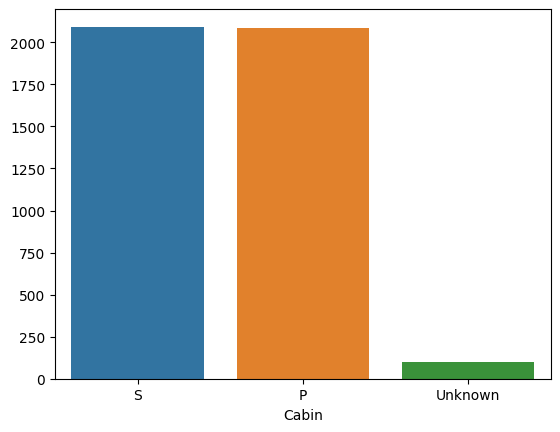

In [24]:
# Берем только последнию букву, оставляем nan значения без изменений
X_pred['Cabin'] = X_pred['Cabin'].apply(process_cabin)

# Строим график
Cabin_pred = X_pred['Cabin'].fillna('Unknown').value_counts()
sns.barplot(x=Cabin_pred.index, y=Cabin_pred.values);

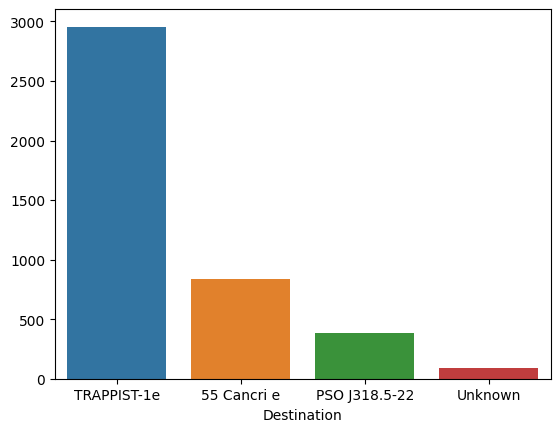

In [25]:
# замена "nan" на случайную категорию кабины
X_pred['Cabin'] = X_pred['Cabin'].apply(lambda x: random.choice(['P', 'S']) if pd.isnull(x) else x)

# преобразование в числовой формат
X_pred['Cabin'] = le.fit_transform(X_pred['Cabin'])

# Строим график
Destination_pred = X_pred['Destination'].fillna('Unknown').value_counts()
sns.barplot(x=Destination_pred.index, y=Destination_pred.values);

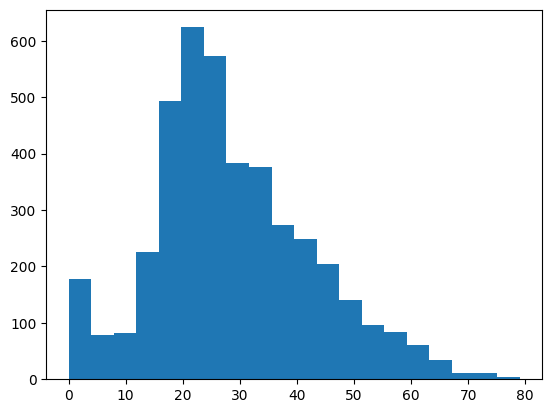

In [26]:
# заменяем пропущенные значения на наиболее часто встречающееся значение
X_pred['Destination'].fillna(X_pred['Destination'].mode()[0], inplace=True)

# преобразование в числовой формат
X_pred['Destination'] = le.fit_transform(X_pred['Destination'])

# создаем график
plt.hist(X_pred['Age'], bins=20)

plt.show()

In [27]:
# создаем датафреймы с пропущенными и заполненными значениями
df_missing_pred = X_pred[X_pred['Age'].isnull()]
df_not_missing_pred = X_pred[X_pred['Age'].notnull()]

# выбираем признаки, которые будем использовать для обучения модели
X_train_pred = df_not_missing_pred[['HomePlanet', 'CryoSleep', 'Cabin', 'VIP', 'Group', 'Number']]
y_train_pred = df_not_missing_pred['Age']

# создаем модель
rf_pred = RandomForestRegressor()

# обучаем модель на имеющихся данных
rf_pred.fit(X_train_pred, y_train_pred)

# предсказываем значения для пропущенных значений
X_test_pred = df_missing_pred[['HomePlanet', 'CryoSleep', 'Cabin', 'VIP', 'Group', 'Number']]
predicted_age_pred = rf_pred.predict(X_test_pred)

# заменяем пропущенные значения на предсказанные
X_pred.loc[X_pred['Age'].isnull(), 'Age'] = predicted_age_pred

# Приводим значения к int
X_pred['Age'] = X_pred['Age'].astype(int)

In [28]:
X_pred[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = X_pred[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(0.0)

# удаляем Name
X_pred = X_pred.drop('Name', axis=1)

print(X_pred.isna().sum())
print('-----')
print(X_pred.dtypes)

HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Group           0
Number          0
dtype: int64
-----
HomePlanet        int32
CryoSleep         int64
Cabin             int32
Destination       int32
Age               int32
VIP               int64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Group             int32
Number            int32
dtype: object


In [29]:
# Шкалируем данные
lst = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Group']
for column in lst:
    df[column] = scale(df[column])
    X_pred[column] = scale(X_pred[column])

<Axes: >

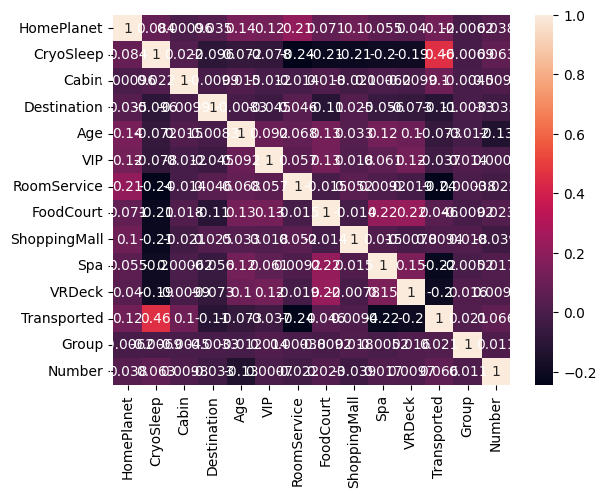

In [30]:
# вычисляем матрицу корреляций
corr_matrix = df.corr()

# создаем тепловую карту для визуализации
sns.heatmap(corr_matrix, annot=True)

In [31]:
# Создаем новые признаки
df['TotalServices'] = df['Cabin'] + df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']

df['HasServices'] = df[['Cabin', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

df['Alone'] = df['Group'].apply(lambda x: 1 if x == 1 else 0)


X_pred['TotalServices'] = X_pred['Cabin'] + X_pred['RoomService'] + X_pred['FoodCourt'] + X_pred['ShoppingMall'] + X_pred['Spa'] + X_pred['VRDeck']

X_pred['HasServices'] =X_pred[['Cabin', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

X_pred['Alone'] = X_pred['Group'].apply(lambda x: 1 if x == 1 else 0)

In [32]:
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,Number,TotalServices,HasServices,Alone
0,1,0,0,2,0.707056,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,-1.734409,1,-1.431339,0,0
1,0,0,1,2,-0.334784,0,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,1,-1.734034,1,0.307723,1,0
2,1,0,1,2,2.026719,1,-0.268001,1.959998,-0.283579,5.695623,-0.219796,0,-1.733660,1,7.884246,1,0
3,1,0,1,2,0.290320,0,-0.333105,0.523010,0.336851,2.687176,-0.092818,0,-1.733660,2,4.121114,1,0
4,0,0,1,2,-0.890431,0,0.125652,-0.237159,-0.031059,0.231374,-0.261240,1,-1.733286,1,0.827569,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,1,0,0,0,0.845968,1,-0.333105,3.992336,-0.283579,1.189173,-0.197751,0,1.738236,1,4.367074,1,0
8689,0,1,1,1,-0.751519,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,1.738984,1,-0.431339,0,0
8690,0,0,1,2,-0.195872,0,-0.333105,-0.281027,2.846999,-0.269737,-0.263003,1,1.739359,1,2.700127,1,0
8691,1,0,1,0,0.220864,0,-0.333105,0.376365,-0.283579,0.043013,2.589576,0,1.739733,1,3.392272,1,0


## Модели

In [33]:
# Разделение данных на признаки и целевую переменную
X = df.drop(['Transported'], axis=1)
y = df['Transported']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Логистическая регрессия

In [34]:
# обучение модели
model = LogisticRegression()
model.fit(X_train, y_train)

# оценка качества модели
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = np.where(y_pred_proba > 0.5, 1, 0)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 score:', f1_score(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.7791834387579069
Precision: 0.759453781512605
Recall: 0.8234624145785877
F1 score: 0.7901639344262296
Confusion matrix:
 [[632 229]
 [155 723]]


In [35]:
# поиск оптимальных гиперпараметров модели
param_grid = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
              'C': [0.01, 0.1, 1, 10, 100],
              'fit_intercept': [True, False],
              'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

C:\python-3.10.11\lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\python-3.10.11\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\python-3.10.11\lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\python-3.10.11\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\python-3.10.11\lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'fit_intercept': [True, False],
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']})

In [36]:
print('Best hyperparameters:', grid_search.best_params_)

Best hyperparameters: {'C': 1, 'fit_intercept': True, 'penalty': 'l2', 'solver': 'lbfgs'}


In [37]:
# повторное обучение модели с оптимальными гиперпараметрами
lr_model = LogisticRegression(**grid_search.best_params_)
lr_model.fit(X_train, y_train)

# оценка качества модели после подбора гиперпараметров
y_pred_proba = lr_model.predict_proba(X_test)[:,1]
y_pred = np.where(y_pred_proba > 0.5, 1, 0)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 score:', f1_score(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy: 0.7791834387579069
Precision: 0.759453781512605
Recall: 0.8234624145785877
F1 score: 0.7901639344262296
Confusion matrix:
 [[632 229]
 [155 723]]


In [38]:
predictions = lr_model.predict(X_pred)

In [39]:
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_lr.csv', index=False)
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


#  (LogisticRegression) Score: 0.79424 на сайте Kaggle. Место в рейтинге = 1196

### Метод опорных векторов (SVM)

In [40]:
# задаем диапазон значений гиперпараметров для поиска
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']}

# создаем SVM модель
svm_model = SVC()

# поиск оптимальных значений гиперпараметров
grid_search = GridSearchCV(svm_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# выводим лучшие значения гиперпараметров
print('Best hyperparameters:', grid_search.best_params_)

# оценка качества модели с использовем кросс-валидации
scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print('Cross-validation scores:', scores)

# оценка качества модели на тестовом наборе данных
accuracy = grid_search.best_estimator_.score(X_test, y_test)
print('Accuracy:', accuracy)

Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Cross-validation scores: [0.78504673 0.80373832 0.7922358  0.80445723 0.80431655]
Accuracy: 0.7889591719378953


In [41]:
predictions = grid_search.best_estimator_.predict(X_pred)
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_svc.csv', index=False)
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


#  (svc) Score: 0.79658 на сайте Kaggle. Место в рейтинге = 1012

### Случайный лес

In [42]:
# создание модели
rf = RandomForestClassifier(random_state=42)

param_grid = {'n_estimators': [50, 100, 200],
              'max_depth': [None, 5, 10],
              'min_samples_split': [2, 5],
              'min_samples_leaf': [1, 2]}

# поиск гиперпараметров
grid_search = GridSearchCV(rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# вывод наилучших гиперпараметров и точности
print('Best hyperparameters:', grid_search.best_params_)
print('Accuracy:', grid_search.best_score_)

Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.7989657045032559


In [43]:
predictions = grid_search.best_estimator_.predict(X_pred)
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_rf.csv', index=False)
output

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


#  (rf) Score: 0.77156 на сайте Kaggle.

### Градиентный бустинг

In [44]:
# Создаем модель градиентного бустинга
gb_model = GradientBoostingClassifier(random_state=42)

# Задаем сетку параметров для перебора
param_grid = {
    'learning_rate': [0.01, 0.001],
    'n_estimators': [500, 1000],
    'max_depth': [5, 10]
}


grid_search = GridSearchCV(gb_model, param_grid=param_grid, cv=5)

# Обучаем модель на данных
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры и метрики качества
print("Best parameters: ", grid_search.best_params_)
print("Train score: ", grid_search.best_score_)
print("Test score: ", grid_search.score(X_test, y_test))

Best parameters:  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}
Train score:  0.7988206817723391
Test score:  0.7929844738355377


In [45]:
predictions = grid_search.best_estimator_.predict(X_pred)
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_gb.csv', index=False)
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


#  (gb) Score: 0.80056 на сайте Kaggle. Место в рейтинге = 724

In [53]:
# Создаем модель и устанавливаем параметры learning_rate, iterations, depth
gb_model = CatBoostClassifier(learning_rate=0.05, iterations=100, depth=10)

# Обучаем модель на тренировочных данных
gb_model.fit(X_train, y_train)

# Предсказываем на тестовых данных
y_pred = gb_model.predict(X_test)

# Вычисляем accuracy модели
accuracy = accuracy_score(y_test, y_pred)

0:	learn: 0.6762893	total: 51ms	remaining: 5.05s
1:	learn: 0.6607225	total: 58.8ms	remaining: 2.88s
2:	learn: 0.6466182	total: 113ms	remaining: 3.64s
3:	learn: 0.6333942	total: 163ms	remaining: 3.91s
4:	learn: 0.6203023	total: 212ms	remaining: 4.03s
5:	learn: 0.6084676	total: 267ms	remaining: 4.18s
6:	learn: 0.5973614	total: 314ms	remaining: 4.17s
7:	learn: 0.5877475	total: 366ms	remaining: 4.21s
8:	learn: 0.5785878	total: 418ms	remaining: 4.22s
9:	learn: 0.5703970	total: 433ms	remaining: 3.89s
10:	learn: 0.5627903	total: 484ms	remaining: 3.92s
11:	learn: 0.5550415	total: 538ms	remaining: 3.94s
12:	learn: 0.5482147	total: 592ms	remaining: 3.96s
13:	learn: 0.5415326	total: 705ms	remaining: 4.33s
14:	learn: 0.5352543	total: 757ms	remaining: 4.29s
15:	learn: 0.5290957	total: 880ms	remaining: 4.62s
16:	learn: 0.5229168	total: 980ms	remaining: 4.78s
17:	learn: 0.5176172	total: 1.11s	remaining: 5.07s
18:	learn: 0.5127138	total: 1.18s	remaining: 5.02s
19:	learn: 0.5084153	total: 1.25s	remaini

In [54]:
print(f"Accuracy: {accuracy}")

Accuracy: 0.7855089131684876


In [48]:
predictions = gb_model.predict(X_pred)
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_gb_cat.csv', index=False)
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


## (gb_cat) Score: 0.80173 на сайте Kaggle. Место в рейтинге = 492

## ансамбль CatBoostClassifier и SVC

In [49]:
# создание моделей для голосования
catboost = CatBoostClassifier(learning_rate=0.05, iterations=100, depth=10)
svc = SVC(kernel='rbf', C=1.0, gamma='auto', cv=5)

# упаковка моделей в список
estimators = [('svm', svc), ('catboost', catboost)]

# создание объединяющей модели 
voting_model = VotingClassifier(estimators)

# обучение модели 
voting_model.fit(X_train, y_train)

# получение предсказаний
y_pred = voting_model.predict(X_test)

# оценка качества модели
acc = accuracy_score(y_test, y_pred)

0:	learn: 0.6762893	total: 42.9ms	remaining: 4.25s
1:	learn: 0.6607225	total: 49.2ms	remaining: 2.41s
2:	learn: 0.6466182	total: 93.7ms	remaining: 3.03s
3:	learn: 0.6333942	total: 137ms	remaining: 3.29s
4:	learn: 0.6203023	total: 182ms	remaining: 3.46s
5:	learn: 0.6084676	total: 227ms	remaining: 3.55s
6:	learn: 0.5973614	total: 277ms	remaining: 3.69s
7:	learn: 0.5877475	total: 325ms	remaining: 3.73s
8:	learn: 0.5785878	total: 369ms	remaining: 3.73s
9:	learn: 0.5703970	total: 381ms	remaining: 3.43s
10:	learn: 0.5627903	total: 426ms	remaining: 3.45s
11:	learn: 0.5550415	total: 471ms	remaining: 3.45s
12:	learn: 0.5482147	total: 522ms	remaining: 3.5s
13:	learn: 0.5415326	total: 569ms	remaining: 3.49s
14:	learn: 0.5352543	total: 613ms	remaining: 3.47s
15:	learn: 0.5290957	total: 659ms	remaining: 3.46s
16:	learn: 0.5229168	total: 703ms	remaining: 3.43s
17:	learn: 0.5176172	total: 750ms	remaining: 3.42s
18:	learn: 0.5127138	total: 802ms	remaining: 3.42s
19:	learn: 0.5084153	total: 850ms	remai

In [50]:
print(f'Accuracy: {acc}')

Accuracy: 0.7924094307073031


In [51]:
predictions = voting_model.predict(X_pred)
output = pd.DataFrame({'PassengerId': df_pred.PassengerId, 'Transported': predictions})
output['Transported'] = output['Transported'].astype(bool)
output.to_csv('submission_.csv', index=False)
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


## Score:  0.79705 на сайте Kaggle. Результат хуже